<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Ideas" data-toc-modified-id="Ideas-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Ideas</a></span></li><li><span><a href="#Libs-and-import-data" data-toc-modified-id="Libs-and-import-data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Libs and import data</a></span></li><li><span><a href="#Data-Wrangle" data-toc-modified-id="Data-Wrangle-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Data Wrangle</a></span><ul class="toc-item"><li><span><a href="#Split-data-train,-test" data-toc-modified-id="Split-data-train,-test-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Split data train, test</a></span></li><li><span><a href="#Fill-NaN-values" data-toc-modified-id="Fill-NaN-values-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Fill NaN values</a></span></li><li><span><a href="#Additional-cleanup" data-toc-modified-id="Additional-cleanup-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Additional cleanup</a></span></li><li><span><a href="#Split-features-(meteorological-inputs)-and-label-(PM2.5)" data-toc-modified-id="Split-features-(meteorological-inputs)-and-label-(PM2.5)-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Split features (meteorological inputs) and label (PM<sub>2.5</sub>)</a></span></li></ul></li><li><span><a href="#Linear-Regression" data-toc-modified-id="Linear-Regression-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Linear Regression</a></span><ul class="toc-item"><li><span><a href="#evaluate-model-performance" data-toc-modified-id="evaluate-model-performance-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>evaluate model performance</a></span></li></ul></li><li><span><a href="#DecisionTree" data-toc-modified-id="DecisionTree-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>DecisionTree</a></span><ul class="toc-item"><li><span><a href="#RandomForest" data-toc-modified-id="RandomForest-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>RandomForest</a></span></li><li><span><a href="#Cross-validation" data-toc-modified-id="Cross-validation-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Cross validation</a></span></li><li><span><a href="#save-model" data-toc-modified-id="save-model-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>save model</a></span></li><li><span><a href="#Grid-Search" data-toc-modified-id="Grid-Search-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Grid Search</a></span></li><li><span><a href="#Analyze-model" data-toc-modified-id="Analyze-model-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>Analyze model</a></span></li><li><span><a href="#Scipy-interval-95%" data-toc-modified-id="Scipy-interval-95%-5.6"><span class="toc-item-num">5.6&nbsp;&nbsp;</span>Scipy interval 95%</a></span></li><li><span><a href="#Ensemble-Methods" data-toc-modified-id="Ensemble-Methods-5.7"><span class="toc-item-num">5.7&nbsp;&nbsp;</span>Ensemble Methods</a></span></li></ul></li><li><span><a href="#DarkSky-Dataset" data-toc-modified-id="DarkSky-Dataset-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>DarkSky Dataset</a></span><ul class="toc-item"><li><span><a href="#Merge-data" data-toc-modified-id="Merge-data-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Merge data</a></span></li><li><span><a href="#Split-train-and-test" data-toc-modified-id="Split-train-and-test-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Split train and test</a></span></li><li><span><a href="#Train-and-validate" data-toc-modified-id="Train-and-validate-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Train and validate</a></span><ul class="toc-item"><li><span><a href="#Trainset" data-toc-modified-id="Trainset-6.3.1"><span class="toc-item-num">6.3.1&nbsp;&nbsp;</span>Trainset</a></span></li><li><span><a href="#Testset" data-toc-modified-id="Testset-6.3.2"><span class="toc-item-num">6.3.2&nbsp;&nbsp;</span>Testset</a></span></li></ul></li></ul></li><li><span><a href="#RMSE" data-toc-modified-id="RMSE-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>RMSE</a></span></li></ul></div>


# Ideas
- Load data from the last exercise (cleaned data including the best combination of MERRA-2 product and observed ground data)
- Let try with simple prediction using Linear Regresssion, Logistic Regression, Decision Tree and RandomForest Regression
- Measured the accurate (or the error) from those technique
- Apply the outcome with a forecast data source such as from DarkSky

# Libs and import data

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import numpy as np

In [5]:
# if you have not install sklearn (or scikit-learn) and scipy then install it
# ! pip install scikit-learn --user
# ! pip install scipy --user

In [6]:
# let pick up the data has been cleaned up the previous exercise, v3
df = pd.read_csv('data/comb_PM25_wind_Hanoi_2018_v3.csv',
                 parse_dates=['DATE'],
                 index_col=['DATE'])
df.head()

,PM2.5,T2MDEW,T2M,PS,TQV,TQL,H1000,DISPH,FRCAN,HLML,RHOA,CIG,WS,CLDCR,v_2m,v_50m,v_850
DATE,,,,,,,,,,,,,,,,,
2018-01-01 01:00:00,69.2,10.79443,13.64376,100865.09,34.909637,0.009235,160.25461,0.256226,1.000000,63.907425,1.216159,NaN,NaN,NaN,0.429060,0.979452,6.175777
2018-01-01 02:00:00,75.5,10.72836,13.33932,100819.56,35.195385,0.006260,156.44829,0.256226,1.000000,63.832478,1.217125,NaN,NaN,NaN,0.383400,0.872296,5.997708
2018-01-01 03:00:00,90.2,10.60630,13.09753,100793.71,35.590984,0.003489,154.54437,0.256104,0.993164,63.766266,1.218085,NaN,NaN,NaN,0.339189,0.729687,5.915825
2018-01-01 04:00:00,97.6,10.50967,12.81360,100791.80,35.827934,0.002314,154.16837,0.255981,0.927490,63.718185,1.218972,NaN,NaN,NaN,0.305853,0.666341,5.885087
2018-01-01 05:00:00,89.1,10.49365,12.71010,100808.45,35.953880,0.001480,155.72943,0.255859,0.786133,63.684280,1.219831,NaN,NaN,NaN,0.258492,0.541109,5.796022


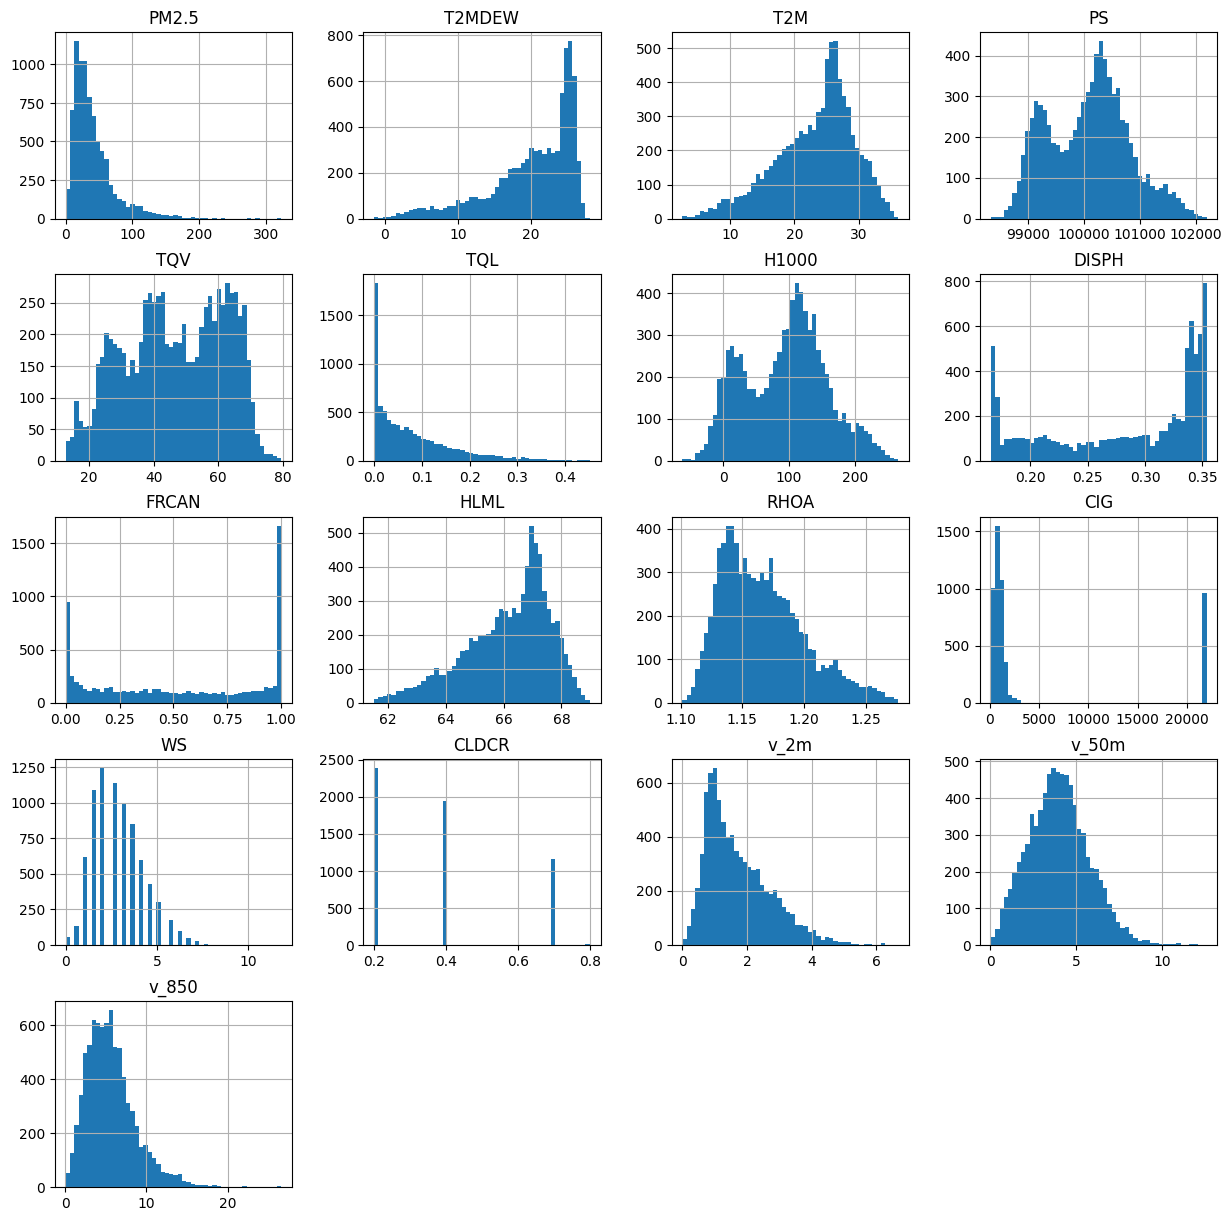

In [7]:
df.hist(bins=50, figsize=(15,15));

# Data Wrangle

## Split data train, test

In [8]:
# the idea is the split the dataset into two parts, one for training, and one for validation
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data)*test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [9]:
# now we can split them with a ratio like this
train_set, test_set = split_train_test(df, 0.2)

In [10]:
len(train_set)

6493

In [11]:
len(test_set)

1623

In [12]:
# however, the sklearn library has such unility 
from sklearn.model_selection import train_test_split

In [13]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=2020)
print(len(train_set))
train_set.head()

6492


,PM2.5,T2MDEW,T2M,PS,TQV,TQL,H1000,DISPH,FRCAN,HLML,RHOA,CIG,WS,CLDCR,v_2m,v_50m,v_850
DATE,,,,,,,,,,,,,,,,,
2018-11-01 01:00:00,66.0,13.76476,15.91640,100623.33,23.115633,0.000000,140.67795,0.346069,0.000000,65.119470,1.190721,NaN,2.1,NaN,1.317137,5.151577,13.778793
2018-03-11 13:00:00,97.1,16.36712,23.94467,100729.96,37.070614,0.095612,151.08076,0.170471,0.558838,65.698654,1.181534,NaN,2.1,0.4,3.250031,4.604924,5.120155
2018-11-02 17:00:00,28.0,15.21340,22.42794,100487.85,20.839620,0.000000,130.45107,0.345093,0.000000,66.063030,1.172179,NaN,1.0,NaN,0.614779,1.535728,3.374469
2018-03-27 23:00:00,63.7,18.28860,18.51727,100447.27,38.934628,0.004002,126.26744,0.192688,0.044815,65.261230,1.186127,22000.0,3.1,NaN,1.117351,4.444736,6.082646
2018-12-01 04:00:00,55.0,20.01226,20.44995,100557.99,42.091070,0.090057,136.40723,0.316406,0.208740,65.746920,1.178689,792.0,1.5,0.4,0.629109,1.737746,5.265891


## Fill NaN values
- Data are likely assembled with missing values
- Regression or machine learning works better with completed dataset

In [14]:
# make a copy and test out
df1 = df.copy(deep=True)

In [15]:
# calculate the median of the Windspeed (WS) input
median = df1['WS'].median()

In [16]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8116 entries, 2018-01-01 01:00:00 to 2018-12-31 00:00:00
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   8116 non-null   float64
 1   T2MDEW  8116 non-null   float64
 2   T2M     8116 non-null   float64
 3   PS      8116 non-null   float64
 4   TQV     8116 non-null   float64
 5   TQL     8116 non-null   float64
 6   H1000   8116 non-null   float64
 7   DISPH   8116 non-null   float64
 8   FRCAN   8092 non-null   float64
 9   HLML    8092 non-null   float64
 10  RHOA    8092 non-null   float64
 11  CIG     5088 non-null   float64
 12  WS      7809 non-null   float64
 13  CLDCR   5502 non-null   float64
 14  v_2m    8116 non-null   float64
 15  v_50m   8116 non-null   float64
 16  v_850   8116 non-null   float64
dtypes: float64(17)
memory usage: 1.1 MB


In [17]:
df1['WS'].fillna(median, inplace=True)

In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8116 entries, 2018-01-01 01:00:00 to 2018-12-31 00:00:00
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   8116 non-null   float64
 1   T2MDEW  8116 non-null   float64
 2   T2M     8116 non-null   float64
 3   PS      8116 non-null   float64
 4   TQV     8116 non-null   float64
 5   TQL     8116 non-null   float64
 6   H1000   8116 non-null   float64
 7   DISPH   8116 non-null   float64
 8   FRCAN   8092 non-null   float64
 9   HLML    8092 non-null   float64
 10  RHOA    8092 non-null   float64
 11  CIG     5088 non-null   float64
 12  WS      8116 non-null   float64
 13  CLDCR   5502 non-null   float64
 14  v_2m    8116 non-null   float64
 15  v_50m   8116 non-null   float64
 16  v_850   8116 non-null   float64
dtypes: float64(17)
memory usage: 1.1 MB


In [19]:
# we can manually do this by for loop
for col in df1.columns:
    df1[col].fillna(df1[col].median(), inplace=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8116 entries, 2018-01-01 01:00:00 to 2018-12-31 00:00:00
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   8116 non-null   float64
 1   T2MDEW  8116 non-null   float64
 2   T2M     8116 non-null   float64
 3   PS      8116 non-null   float64
 4   TQV     8116 non-null   float64
 5   TQL     8116 non-null   float64
 6   H1000   8116 non-null   float64
 7   DISPH   8116 non-null   float64
 8   FRCAN   8116 non-null   float64
 9   HLML    8116 non-null   float64
 10  RHOA    8116 non-null   float64
 11  CIG     8116 non-null   float64
 12  WS      8116 non-null   float64
 13  CLDCR   8116 non-null   float64
 14  v_2m    8116 non-null   float64
 15  v_50m   8116 non-null   float64
 16  v_850   8116 non-null   float64
dtypes: float64(17)
memory usage: 1.1 MB


In [20]:
# and sklearn has the Class to do such 
from sklearn.impute import SimpleImputer

In [21]:
inputer = SimpleImputer(strategy='median')

In [22]:
df2 =df.copy(deep=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8116 entries, 2018-01-01 01:00:00 to 2018-12-31 00:00:00
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   8116 non-null   float64
 1   T2MDEW  8116 non-null   float64
 2   T2M     8116 non-null   float64
 3   PS      8116 non-null   float64
 4   TQV     8116 non-null   float64
 5   TQL     8116 non-null   float64
 6   H1000   8116 non-null   float64
 7   DISPH   8116 non-null   float64
 8   FRCAN   8092 non-null   float64
 9   HLML    8092 non-null   float64
 10  RHOA    8092 non-null   float64
 11  CIG     5088 non-null   float64
 12  WS      7809 non-null   float64
 13  CLDCR   5502 non-null   float64
 14  v_2m    8116 non-null   float64
 15  v_50m   8116 non-null   float64
 16  v_850   8116 non-null   float64
dtypes: float64(17)
memory usage: 1.1 MB


In [23]:
# evaluate df2 
inputer.fit(df2)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [24]:
# see the statistic, median in this case
inputer.statistics_

array([3.20000000e+01, 2.17670550e+01, 2.45143500e+01, 1.00156612e+05,
       4.69396705e+01, 5.37109380e-02, 1.01305442e+02, 3.08166505e-01,
       5.11840850e-01, 6.64740250e+01, 1.16165940e+00, 9.45000000e+02,
       2.60000000e+00, 4.00000000e-01, 1.48621393e+00, 3.92495231e+00,
       5.23608490e+00])

In [25]:
# transform is doing the work
df2full = inputer.transform(df1)

In [26]:
type(df2full)

numpy.ndarray

In [27]:
# convert the inputed dataset and  compared
df2 = pd.DataFrame(data=df2full, columns=df1.columns)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8116 entries, 0 to 8115
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   8116 non-null   float64
 1   T2MDEW  8116 non-null   float64
 2   T2M     8116 non-null   float64
 3   PS      8116 non-null   float64
 4   TQV     8116 non-null   float64
 5   TQL     8116 non-null   float64
 6   H1000   8116 non-null   float64
 7   DISPH   8116 non-null   float64
 8   FRCAN   8116 non-null   float64
 9   HLML    8116 non-null   float64
 10  RHOA    8116 non-null   float64
 11  CIG     8116 non-null   float64
 12  WS      8116 non-null   float64
 13  CLDCR   8116 non-null   float64
 14  v_2m    8116 non-null   float64
 15  v_50m   8116 non-null   float64
 16  v_850   8116 non-null   float64
dtypes: float64(17)
memory usage: 1.1 MB


In [28]:
# you can save to a file with all missing values filled
df.to_csv('data/filled_PM2.5_Hanoi_2018.csv')

(0.0, 200.0)

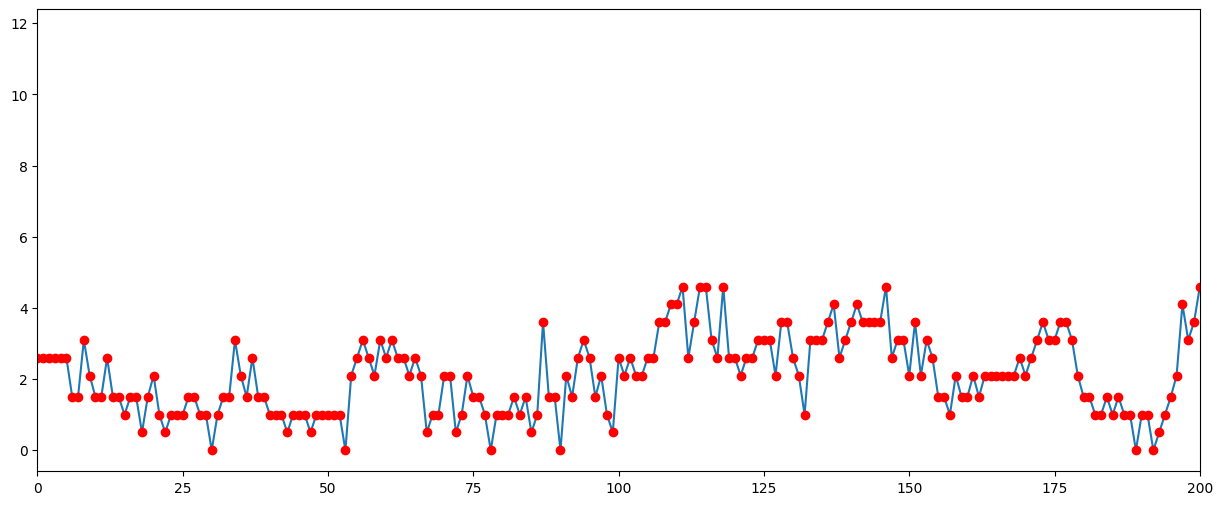

In [29]:
# let see if they are matched
fig, ax = plt.subplots(figsize=(15,6))
ax.plot(df1.WS.to_list())
ax.plot(df2.WS, 'ro')
ax.set_xlim(0,200)

## Additional cleanup

<Axes: >

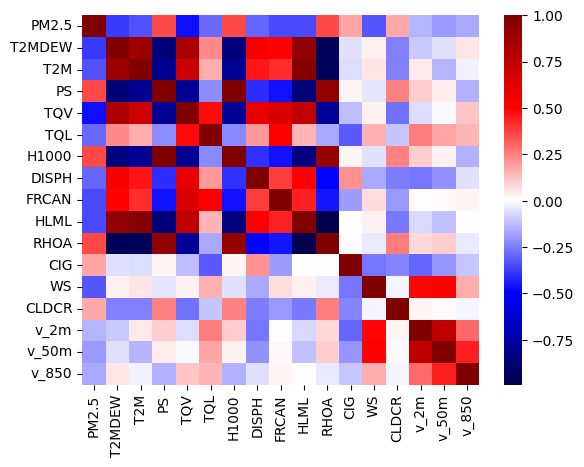

In [30]:
# let return back to the original dataset (df) before fill up NaN
sns.heatmap(df.corr(), cmap='seismic')

<Axes: >

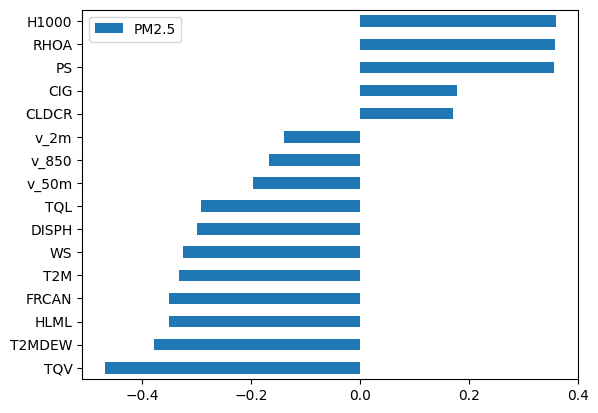

In [31]:
# and only correlation with PM2.5
df.corr()['PM2.5'].sort_values().to_frame().drop('PM2.5').plot.barh()

In [32]:
df.columns

Index(['PM2.5', 'T2MDEW', 'T2M', 'PS', 'TQV', 'TQL', 'H1000', 'DISPH', 'FRCAN',
       'HLML', 'RHOA', 'CIG', 'WS', 'CLDCR', 'v_2m', 'v_50m', 'v_850'],
      dtype='object')

In [33]:
# drop some columns either weak in correation or dependent (redundant) to other inputs
df.drop(columns=['CLDCR', 'v_2m', 'v_50m', 'v_850', 'FRCAN', 'DISPH'], inplace=True)

In [34]:
df.head()

,PM2.5,T2MDEW,T2M,PS,TQV,TQL,H1000,HLML,RHOA,CIG,WS
DATE,,,,,,,,,,,
2018-01-01 01:00:00,69.2,10.79443,13.64376,100865.09,34.909637,0.009235,160.25461,63.907425,1.216159,NaN,NaN
2018-01-01 02:00:00,75.5,10.72836,13.33932,100819.56,35.195385,0.006260,156.44829,63.832478,1.217125,NaN,NaN
2018-01-01 03:00:00,90.2,10.60630,13.09753,100793.71,35.590984,0.003489,154.54437,63.766266,1.218085,NaN,NaN
2018-01-01 04:00:00,97.6,10.50967,12.81360,100791.80,35.827934,0.002314,154.16837,63.718185,1.218972,NaN,NaN
2018-01-01 05:00:00,89.1,10.49365,12.71010,100808.45,35.953880,0.001480,155.72943,63.684280,1.219831,NaN,NaN


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8116 entries, 2018-01-01 01:00:00 to 2018-12-31 00:00:00
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   8116 non-null   float64
 1   T2MDEW  8116 non-null   float64
 2   T2M     8116 non-null   float64
 3   PS      8116 non-null   float64
 4   TQV     8116 non-null   float64
 5   TQL     8116 non-null   float64
 6   H1000   8116 non-null   float64
 7   HLML    8092 non-null   float64
 8   RHOA    8092 non-null   float64
 9   CIG     5088 non-null   float64
 10  WS      7809 non-null   float64
dtypes: float64(11)
memory usage: 760.9 KB


## Split features (meteorological inputs) and label (PM<sub>2.5</sub>)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8116 entries, 2018-01-01 01:00:00 to 2018-12-31 00:00:00
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   8116 non-null   float64
 1   T2MDEW  8116 non-null   float64
 2   T2M     8116 non-null   float64
 3   PS      8116 non-null   float64
 4   TQV     8116 non-null   float64
 5   TQL     8116 non-null   float64
 6   H1000   8116 non-null   float64
 7   HLML    8092 non-null   float64
 8   RHOA    8092 non-null   float64
 9   CIG     5088 non-null   float64
 10  WS      7809 non-null   float64
dtypes: float64(11)
memory usage: 760.9 KB


In [37]:
# let make X as the matrix for the feature (or inputs)
X = df.drop('PM2.5', axis=1)

In [38]:
# and lowercase y as the label (or the value of the target)
y = df['PM2.5'].copy()

In [39]:
# let build the inpute instance to work with whole data at one
# to inpute more than one columns, we can use this 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [40]:
# transform data from real value to a relative to the set
from sklearn.preprocessing import StandardScaler

In [41]:
# we have all column with numeric values
num_attrs = list(df.columns)
num_attrs.remove('PM2.5')
num_attrs

['T2MDEW', 'T2M', 'PS', 'TQV', 'TQL', 'H1000', 'HLML', 'RHOA', 'CIG', 'WS']

In [42]:
# first is the trategy for inputer using median
# then convert the absolute value in the each column using the Standard Class
num_pipeline = Pipeline([
        ('inputer', SimpleImputer(strategy='median')),
        ('std_scaler', StandardScaler()),
        ])

In [43]:
# and instance to tranform all column at one
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attrs)
])

In [44]:
# or building a function to do all in one step
def inpute_transfrom(data=None):
    num_pipeline = Pipeline([
        ('inputer', SimpleImputer(strategy='median')),
        ('std_scaler', StandardScaler()),
        ])
    num_attrs = list(data.columns)
    full_pipeline = ColumnTransformer([
        ('num', num_pipeline, num_attrs)
        ])
    return full_pipeline.fit_transform(data) # return a numpy array

In [45]:
X_scaled = inpute_transfrom(data=X)

In [46]:
# how do we know that the data has been fixed properly
X_scaled_test = inpute_transfrom(data=X)
dft = pd.DataFrame(data=X_scaled_test, columns=num_attrs)
dft.info()
# looking good
del dft

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8116 entries, 0 to 8115
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T2MDEW  8116 non-null   float64
 1   T2M     8116 non-null   float64
 2   PS      8116 non-null   float64
 3   TQV     8116 non-null   float64
 4   TQL     8116 non-null   float64
 5   H1000   8116 non-null   float64
 6   HLML    8116 non-null   float64
 7   RHOA    8116 non-null   float64
 8   CIG     8116 non-null   float64
 9   WS      8116 non-null   float64
dtypes: float64(10)
memory usage: 634.2 KB


In [47]:
# now we can split data, the test_size is the portion of data use for validation
# random_state is to provide consistent if you want to replicate the result
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size=0.33, random_state=2020)

In [48]:
len(X_train), len(X_test)

(5437, 2679)

# Linear Regression

In [49]:
# Linear regression is the simplest form of data learning, let try this first
from sklearn.linear_model import LinearRegression

In [50]:
# make an instant of the class
lin_reg = LinearRegression()

In [51]:
# and training the model using the _train dataset
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
lin_reg.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [53]:
# let see the output of the mode
lin_reg.coef_

array([  -3.15806877,    9.23068653, -237.20129647,  -11.37237178,
         -1.51486159,  216.26310513,   19.10913327,   47.2122002 ,
          2.99459991,   -8.55437448])

In [54]:
# predict based on the training set
y_train_prd = lin_reg.predict(X_train)

(0.0, 500.0)

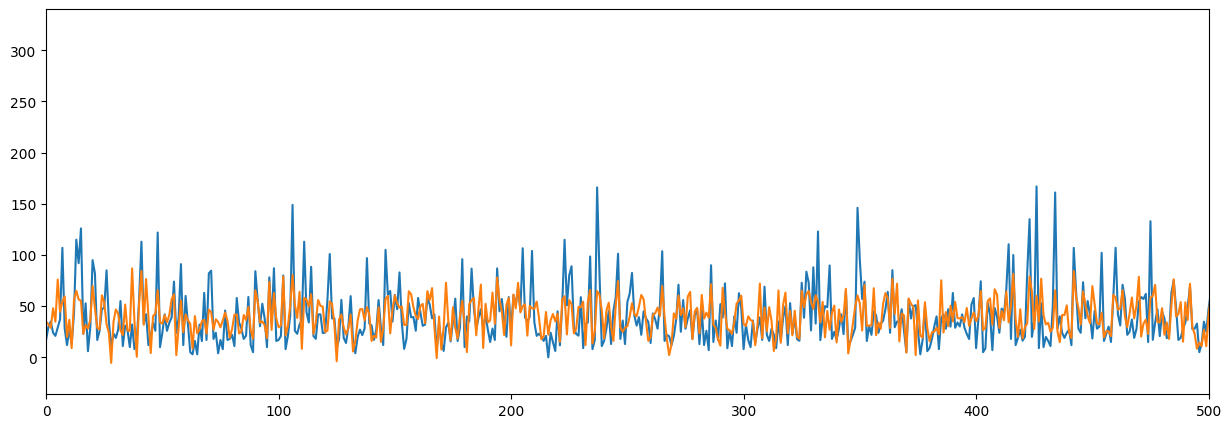

In [55]:
# let see how the label (y_train), and predicting of the label (y_prd)
plt.figure(figsize=(15,5))
plt.plot(y_train.to_list())
plt.plot(y_train_prd)
plt.xlim(0,500)

In [56]:
# more important, how about with validation set (test set)
y_test_prd = lin_reg.predict(X_test)

(0.0, 500.0)

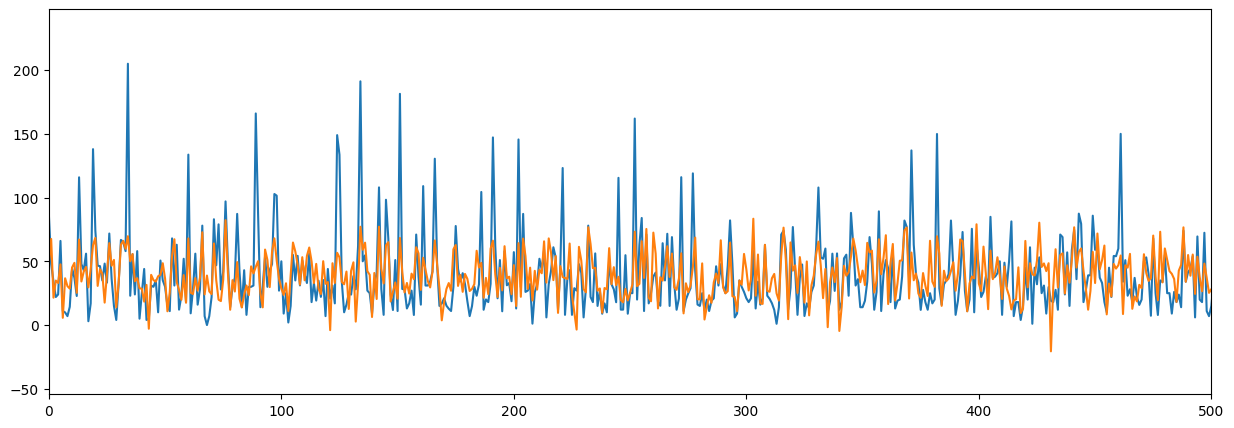

In [57]:
plt.figure(figsize=(15,5))
plt.plot(y_test.to_list())
plt.plot(y_test_prd)
plt.xlim(0,500)

- kind of there, but not easy to assess

## evaluate model performance

In [58]:
# for numeric data, one simple way to to see how far 
# between the prediction and the garget
from sklearn.metrics import mean_squared_error

In [59]:
# on training set
lin_train_mse = mean_squared_error(y_train, y_train_prd)
print('Trainset: Root Squared Mean Error', np.sqrt(lin_train_mse))

Trainset: Root Squared Mean Error 25.50502509220003


In [60]:
# on test set
lin_test_mse = mean_squared_error(y_test, y_test_prd)
print('Test set: Root Squared Mean Error', np.sqrt(lin_test_mse))

Test set: Root Squared Mean Error 25.924922211091516


In [61]:
# the average value label set (y set)
y.mean()

np.float64(40.758735830458356)

In [62]:
# relative error
print(f'Relative Error: {100*np.sqrt(lin_test_mse)/y.mean():.0f}%')

Relative Error: 64%


- underfitting (data), we have can predict the PM<sub>2.5</sub> concentration, but bear in mind the value can be off 64% (up and down), and that only works 66 out of 100 chances (given the error is random)
- let try another model, also, make a dictionary to keep the score between model

In [63]:
results = dict()
def add_stats(model=None, train_rmse=None, test_rmse=None):
    global results
    results[model] = {'train_rmse': round(train_rmse,1),
                     'test_rmse': round(test_rmse, 1)}
    return None

In [64]:
add_stats(model='linear reg', 
         train_rmse=np.sqrt(lin_train_mse), 
         test_rmse=np.sqrt(lin_test_mse))
results

{'linear reg': {'train_rmse': np.float64(25.5), 'test_rmse': np.float64(25.9)}}

# DecisionTree

In [65]:
# let try the same approach with decision tree
from sklearn.tree import DecisionTreeRegressor

In [66]:
tree_reg = DecisionTreeRegressor()

In [67]:
tree_reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [68]:
tree_reg.feature_importances_

array([0.28899826, 0.06637773, 0.0651593 , 0.140332  , 0.10361348,
       0.05440987, 0.05277838, 0.04122784, 0.07101213, 0.11609102])

In [69]:
tree_ytrain_d = tree_reg.predict(X_train)

In [70]:
# no error, too good!
tree_train_rmse = np.sqrt(mean_squared_error(y_train, tree_ytrain_d))
tree_train_rmse

np.float64(0.0)

In [71]:
tree_ytest_d = tree_reg.predict(X_test)

In [72]:
tree_test_rmse = np.sqrt(mean_squared_error(y_test, tree_ytest_d))
tree_test_rmse # higher than regression, 

np.float64(27.917956976860815)

In [73]:
# let bag the result
add_stats(model='decisiontree reg',
         train_rmse=tree_train_rmse,
         test_rmse=tree_test_rmse)
results

{'linear reg': {'train_rmse': np.float64(25.5), 'test_rmse': np.float64(25.9)},
 'decisiontree reg': {'train_rmse': np.float64(0.0),
  'test_rmse': np.float64(27.9)}}

In [74]:
# the results by train set and test set are rather different, to see it
def plot_prediction(label=None, prediction=None, limit=200):
    plt.figure(figsize=(14,6))
    plt.plot(label.to_list())
    plt.plot(prediction, 'ro')
    plt.xlim(0, limit)
    return None

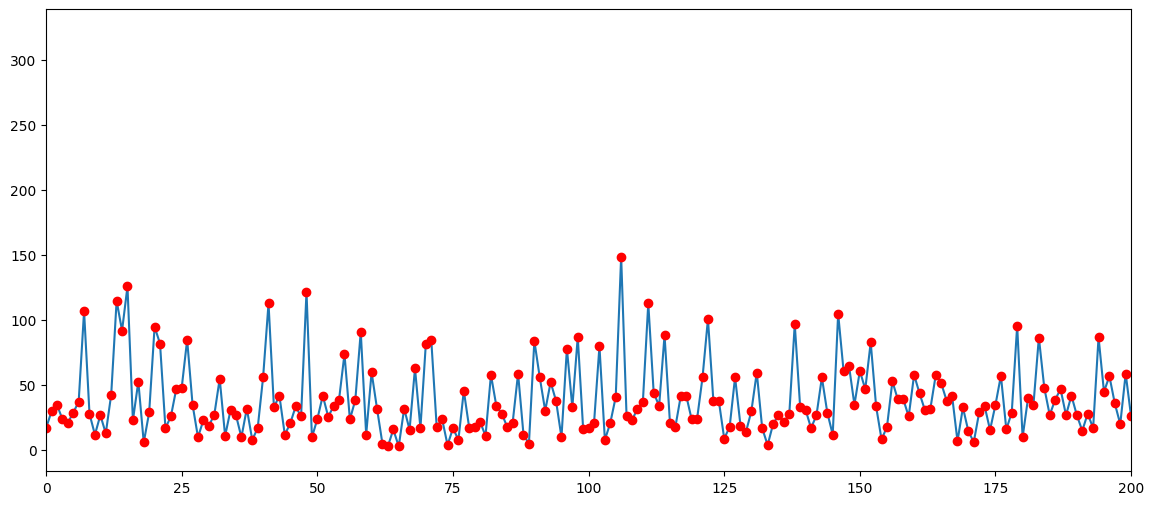

In [75]:
plot_prediction(y_train, tree_ytrain_d)

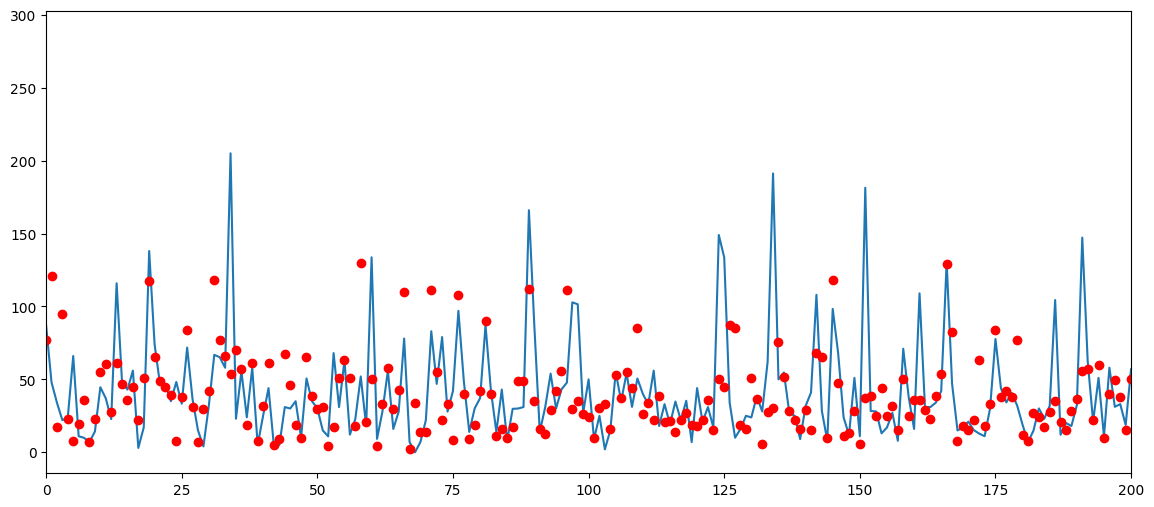

In [76]:
plot_prediction(y_test, tree_ytest_d)

- overfitting data for training set (memorization), and underfitting with test set (not map key feature)

## RandomForest

In [77]:
# more powerful model
from sklearn.ensemble import RandomForestRegressor

In [78]:
forest_reg = RandomForestRegressor()
forest_reg.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
forest_ytrain_p = forest_reg.predict(X_train)

In [80]:
mse_train = mean_squared_error(y_train, forest_ytrain_p)
rmse_train = np.sqrt(mse_train)
rmse_train

np.float64(7.292508857759467)

In [81]:
# test set
forest_ytest_p = forest_reg.predict(X_test)

In [82]:
mse_test = mean_squared_error(y_test, forest_ytest_p)
rmse_test = np.sqrt(mse_test)
rmse_test

np.float64(20.028366668008765)

In [83]:
add_stats(model='randomforest reg',
         train_rmse=rmse_train,
         test_rmse=rmse_test)
results

{'linear reg': {'train_rmse': np.float64(25.5), 'test_rmse': np.float64(25.9)},
 'decisiontree reg': {'train_rmse': np.float64(0.0),
  'test_rmse': np.float64(27.9)},
 'randomforest reg': {'train_rmse': np.float64(7.3),
  'test_rmse': np.float64(20.0)}}

## Cross validation

In [84]:
from sklearn.model_selection import cross_val_score

In [85]:
scores = cross_val_score(tree_reg, X_train, y_train,
                        scoring='neg_mean_squared_error', cv=10)

In [86]:
tree_rmse_scores = np.sqrt(-scores)
tree_rmse_scores

array([25.44814039, 28.16708355, 24.51353543, 29.21121863, 27.15688354,
       31.32098262, 26.07884891, 32.29970722, 28.00581103, 27.42125945])

In [87]:
def display_scores(scores):
    print("Scores: ", scores)
    print("Mean: ", scores.mean())
    print("Standard Deviation: ", scores.std())

In [88]:
display_scores(scores)

Scores:  [ -647.60784926  -793.38459559  -600.91341912  -853.29529412
  -737.49632353  -981.00395221  -680.10636029 -1043.27108656
  -784.3254512   -751.92546961]
Mean:  -787.332980148413
Standard Deviation:  133.01118410091726


In [89]:
lin_scores = cross_val_score(lin_reg, X_train, y_train, 
                             scoring='neg_mean_squared_error', cv=10)

In [90]:
display_scores(lin_scores)

Scores:  [-550.85870613 -723.57425609 -604.74504505 -774.75436464 -558.6424609
 -650.90144343 -694.9417229  -791.12250196 -464.54518714 -719.45029524]
Mean:  -653.3535983471007
Standard Deviation:  101.11405749157913


In [91]:
forest_scores = cross_val_score(forest_reg, X_train, y_train, 
                                scoring='neg_mean_squared_error', cv=10)

In [92]:
display_scores(forest_scores)

Scores:  [-343.11782065 -407.21444692 -345.62024489 -484.02885629 -336.27470965
 -346.0969254  -415.17353085 -554.80194125 -262.71722379 -404.61969415]
Mean:  -389.96653938312306
Standard Deviation:  78.94755668124583


In [93]:
# how about on test set:
for model in [lin_reg, tree_reg, forest_reg]:
    scores = cross_val_score(model, X_test, y_test, 
                             scoring='neg_mean_squared_error', cv=10)
    display_scores(scores)
    print('-'*40)
    

Scores:  [-771.63467574 -554.4382247  -813.16490696 -717.49508355 -598.56766015
 -632.13746509 -569.73439949 -753.33939901 -661.54505262 -680.24197289]
Mean:  -675.2298840188973
Standard Deviation:  83.59053107056987
----------------------------------------


Scores:  [-1258.96932836  -754.32455224 -1090.91089552 -1069.75962687
  -742.94720149  -953.48697761  -801.54794776  -832.95481343
  -826.31220149  -912.99779026]
Mean:  -924.4211335038292
Standard Deviation:  160.21698856067107
----------------------------------------


Scores:  [-597.85776553 -373.35799837 -570.62396724 -515.47484197 -327.54843124
 -456.44067293 -325.49727019 -492.26280919 -537.90035254 -445.76374162]
Mean:  -464.27278508008277
Standard Deviation:  91.98002462447212
----------------------------------------


- look like the RandomForest Regression performs a bit better than the first two

## save model

In [94]:
# just in case you want to save your work
import joblib

In [95]:
# import os
# os.makedirs('model')

In [96]:
joblib.dump(forest_reg, 'model/forest_reg.pkl' )

['model/forest_reg.pkl']

## Grid Search

In [97]:
# we want to model performs better, in this case we tune the hyperparameters
from sklearn.model_selection import GridSearchCV

In [98]:
param_grid = [{'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
              {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},]

In [99]:
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5, 
                           scoring='neg_mean_squared_error',
                          return_train_score=True)

In [100]:
grid_search.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,10


In [101]:
# and see the best estimator
grid_search.best_estimator_

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [102]:
# or best parameters
grid_search.best_params_

{'bootstrap': False, 'max_features': 4, 'n_estimators': 10}

In [103]:
# or see the how each combination has worked
cvres = grid_search.cv_results_

In [104]:
for mean_score, params in zip(cvres['mean_test_score'], cvres['params']):
    print(round(np.sqrt(-mean_score),2), params)

24.3 {'max_features': 2, 'n_estimators': 3}
20.86 {'max_features': 2, 'n_estimators': 10}
20.27 {'max_features': 2, 'n_estimators': 30}
23.07 {'max_features': 4, 'n_estimators': 3}
20.72 {'max_features': 4, 'n_estimators': 10}
20.15 {'max_features': 4, 'n_estimators': 30}
23.51 {'max_features': 6, 'n_estimators': 3}
20.89 {'max_features': 6, 'n_estimators': 10}
20.06 {'max_features': 6, 'n_estimators': 30}
23.66 {'max_features': 8, 'n_estimators': 3}
20.85 {'max_features': 8, 'n_estimators': 10}
20.1 {'max_features': 8, 'n_estimators': 30}
23.25 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
20.73 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
23.4 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
20.07 {'bootstrap': False, 'max_features': 3, 'n_estimators': 10}
22.69 {'bootstrap': False, 'max_features': 4, 'n_estimators': 3}
20.05 {'bootstrap': False, 'max_features': 4, 'n_estimators': 10}


- so the best case with Random Forecast is 19.98 (&mu;g/m<sup>3</sup>) as the standard deviation

## Analyze model

In [105]:
# could look back to see how the weight of each input
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([0.19596797, 0.06997493, 0.085602  , 0.17323084, 0.09732323,
       0.0648059 , 0.07275322, 0.06243923, 0.07471807, 0.10318462])

In [106]:
sorted(zip(feature_importances, X.columns), reverse=True)

[(np.float64(0.19596796965601437), 'T2MDEW'),
 (np.float64(0.173230843473612), 'TQV'),
 (np.float64(0.10318461895130202), 'WS'),
 (np.float64(0.09732322768330486), 'TQL'),
 (np.float64(0.08560199972470146), 'PS'),
 (np.float64(0.07471806831048189), 'CIG'),
 (np.float64(0.07275321547269906), 'HLML'),
 (np.float64(0.06997492916746183), 'T2M'),
 (np.float64(0.06480590198597569), 'H1000'),
 (np.float64(0.06243922557444686), 'RHOA')]

- so the total liquid volumn and dewpoint influences PM<sub>2.5</sub> more than the air temperature or surface level height

In [107]:
# let see how grid search performs
# train set
grid_ytrain_p = grid_search.predict(X_train)
grid_mse = mean_squared_error(y_train, grid_ytrain_p)
grid_train_rmse = np.sqrt(grid_mse)
grid_train_rmse

np.float64(5.306217737324638e-15)

In [108]:
# let see how the prediction look like after hypertunning
# test set
grid_ytest_p = grid_search.predict(X_test)
grid_test_mse = mean_squared_error(y_test, grid_ytest_p)
grid_test_rmse = np.sqrt(grid_test_mse)
grid_test_rmse

np.float64(20.05395079103435)

In [109]:
# still more to work with, but let bag the result for later comparison
add_stats(model='gridsearch',
         train_rmse=grid_train_rmse,
         test_rmse=grid_test_rmse)
results

{'linear reg': {'train_rmse': np.float64(25.5), 'test_rmse': np.float64(25.9)},
 'decisiontree reg': {'train_rmse': np.float64(0.0),
  'test_rmse': np.float64(27.9)},
 'randomforest reg': {'train_rmse': np.float64(7.3),
  'test_rmse': np.float64(20.0)},
 'gridsearch': {'train_rmse': np.float64(0.0), 'test_rmse': np.float64(20.1)}}

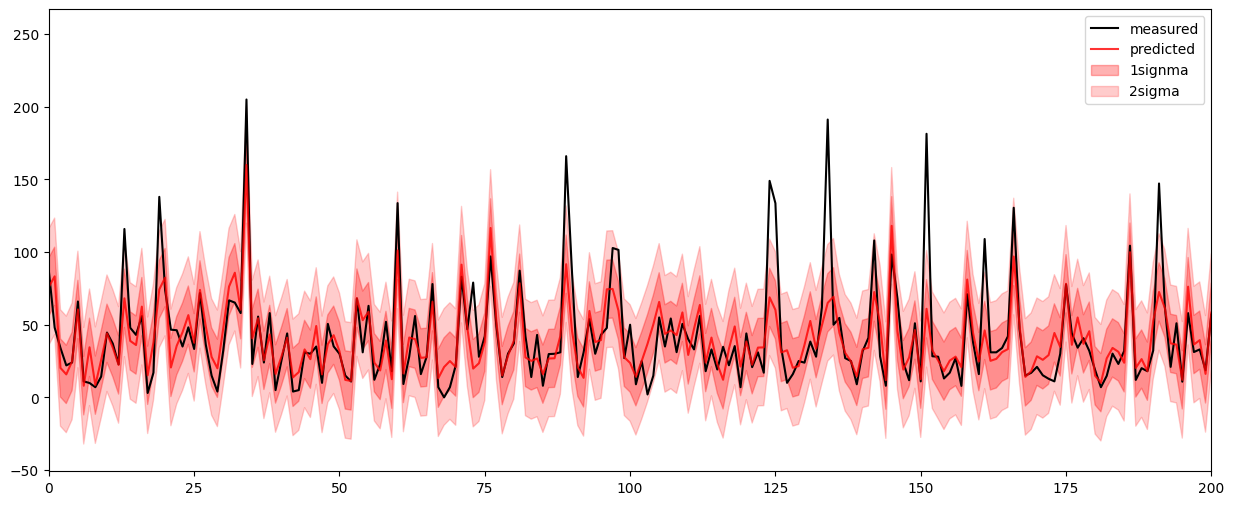

In [110]:
# let visualize it
std_ = grid_test_rmse
xindex = np.arange(0, len(y_test))
fig, ax = plt.subplots(figsize=(15,6))
ax.plot(y_test.to_list(), color='black', label='measured')
ax.plot(grid_ytest_p, color='red', alpha=0.8, label='predicted')
ax.fill_between(xindex, grid_ytest_p-std_,grid_ytest_p+std_, 
                color='red', alpha=0.3, label='1signma' )
ax.fill_between(xindex, grid_ytest_p-2*std_,grid_ytest_p+2*std_, 
                color='red', alpha=0.2, label = '2sigma')
ax.set_xlim(0,200)
ax.legend()

- an easy way to make sure the prediction range captures the real value is to increase the band, and so enlarge the uncertainty
- but let see how confidence we have on the RSME, 

## Scipy interval 95%

In [111]:
# let use stats from scipy library
from scipy import stats

In [112]:
# and look confidence of .95, or the area that a value will be inside the range with 95 chances of 100
confidence = 0.95

In [113]:
squared_errors = (grid_ytest_p - y_test)**2

In [114]:
np.sqrt(stats.t.interval(
    confidence, 
    len(squared_errors)-1,
    loc=squared_errors.mean(),
    scale=stats.sem(squared_errors)))

array([18.82107624, 21.21530047])

- so we are pretty sure that standard deviation from grid search is from 18.8 to 21.1 
- how confidience: 95 chances out of 100, this RMSE will be within this range

## Ensemble Methods

In [115]:
# let look at a final approach to combine three regression we have so far using Voting method
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression

In [116]:
from sklearn.tree import DecisionTreeRegressor

In [117]:
# re-define an instance, all training in the previous sessions are gone
lin_reg  = LinearRegression()
tree_reg = DecisionTreeRegressor()
rnd_reg = RandomForestRegressor()

In [118]:
# and make each model as an parameter for then ensemble (voting)
voting_reg = VotingRegressor(
    estimators=[('lin', lin_reg),
               ('rnd', rnd_reg),
               ('tree', tree_reg)
               ],
)

In [119]:
# train model by the train set
voting_reg.fit(X_train, y_train)

,estimators,"[('lin', ...), ('rnd', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,n_estimators,100
,criterion,'squared_error'


In [120]:
# check estimator (paramters)
voting_reg.estimators_

[LinearRegression(), RandomForestRegressor(), DecisionTreeRegressor()]

In [121]:
# now we do predicting on the test set
y_entest_p = voting_reg.predict(X_test)

In [122]:
mse = mean_squared_error(y_entest_p, y_test)
en_test = np.sqrt(mse)

In [123]:
# we could run on train set
y_entrain_p = voting_reg.predict(X_train)
mse = mean_squared_error(y_entrain_p, y_train)
en_train = np.sqrt(mse)

In [124]:
en_test, en_train

(np.float64(21.8652600395874), np.float64(10.54839849840094))

In [125]:
# still in 21 for test set
add_stats(model='voting reg',
         train_rmse=en_train,
         test_rmse=en_test)
results

{'linear reg': {'train_rmse': np.float64(25.5), 'test_rmse': np.float64(25.9)},
 'decisiontree reg': {'train_rmse': np.float64(0.0),
  'test_rmse': np.float64(27.9)},
 'randomforest reg': {'train_rmse': np.float64(7.3),
  'test_rmse': np.float64(20.0)},
 'gridsearch': {'train_rmse': np.float64(0.0), 'test_rmse': np.float64(20.1)},
 'voting reg': {'train_rmse': np.float64(10.5), 'test_rmse': np.float64(21.9)}}

(200.0, 300.0)

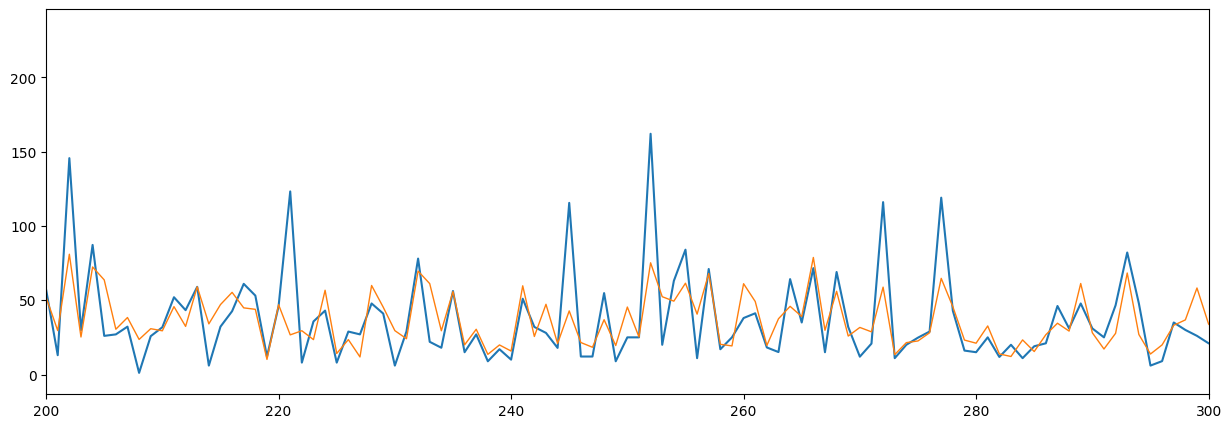

In [126]:
# let visualize the data from Ensemble with test set
plt.figure(figsize=(15,5))
plt.plot(y_test.to_list())
plt.plot(y_entest_p, lw=1)
plt.xlim(200,300)

- so we can get a RMSE = 20 from several model, which is about 50% as the relative standard deviation
- this dataset is combined from several source, but not easy to get from a forecast product (in fact, I am struggling to get those), so we will try out a dataset with less feastures, 

## Additional model comparison

This section adds a stronger baseline and several additional models on the same `X_train`, `X_test`, `y_train`, and `y_test` split used above.

In [127]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
import pandas as pd
import numpy as np

model_results = []

def add_model_result(name, y_true, y_pred):
    model_results.append({
        'model': name,
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    })


In [128]:

baseline_pred = np.full(len(y_test), y_train.mean())
add_model_result('baseline_mean', y_test, baseline_pred)

lin_ref = LinearRegression()
lin_ref.fit(X_train, y_train)
lin_pred = lin_ref.predict(X_test)
add_model_result('linear_regression', y_test, lin_pred)

poly_ridge = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    RidgeCV(alphas=np.logspace(-2, 4, 20))
)
poly_ridge.fit(X_train, y_train)
poly_pred = poly_ridge.predict(X_test)
add_model_result('poly2_ridge', y_test, poly_pred)

rf_cmp = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_cmp.fit(X_train, y_train)
rf_pred = rf_cmp.predict(X_test)
add_model_result('random_forest', y_test, rf_pred)

et_cmp = ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1)
et_cmp.fit(X_train, y_train)
et_pred = et_cmp.predict(X_test)
add_model_result('extra_trees', y_test, et_pred)

hgb_cmp = HistGradientBoostingRegressor(random_state=42)
hgb_cmp.fit(X_train, y_train)
hgb_pred = hgb_cmp.predict(X_test)
add_model_result('hist_gradient_boosting', y_test, hgb_pred)

results_df = pd.DataFrame(model_results).sort_values('rmse').reset_index(drop=True)
results_df


,model,rmse,mae,r2
0,extra_trees,19.457263,12.596649,0.631125
1,random_forest,20.036212,13.298848,0.608847
2,hist_gradient_boosting,20.589720,13.989888,0.586937
3,poly2_ridge,24.151933,16.731072,0.431646
4,linear_regression,25.924922,18.156340,0.345137
5,baseline_mean,32.045152,23.317049,-0.000553


In [129]:

results_df.style.format({'rmse': '{:.3f}', 'mae': '{:.3f}', 'r2': '{:.3f}'})


,model,rmse,mae,r2
0,extra_trees,19.457,12.597,0.631
1,random_forest,20.036,13.299,0.609
2,hist_gradient_boosting,20.590,13.990,0.587
3,poly2_ridge,24.152,16.731,0.432
4,linear_regression,25.925,18.156,0.345
5,baseline_mean,32.045,23.317,-0.001
